In [312]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests
from math import pi
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

In [313]:
city_info = {
    'new york': 'United States',
    'delhi': 'India',
    'mumbai': 'India',
    'islamabad': 'Pakistan',
    'dhaka': 'Bangladesh', 
    'rio de janeiro': 'Brazil',
    'mexico city': 'Mexico',
    'beijing': 'China',
    'tokyo': 'Japan',
    'auckland': 'New Zealand',
    'bangkok': 'Thailand', 
    'toronto': 'Canada',
    'bangalore': 'India'
}

df = pd.DataFrame({
    'City': [],
    'Country': [],
    'CO2 Concentration': [],
    'NO2 Concentration': [],
    'O3 Concentration': [],
    'SO2 Concentration': [],
    'PM2.5 Concentration': [],
    'PM10 Concentration': [],
    'Overall AQI': []
})


In [314]:
city = 'new york'
api_url = 'https://api.api-ninjas.com/v1/airquality?city={}'.format(city)
valid = requests.get(api_url, headers={'X-Api-Key': 'TePJvl5FMrdJXSuzGe5bsQ==gx19rDh6N9q5dbgh'})

if valid.status_code == 200:
    data = valid.json()
    print('API is valid')
else:
    print(f"Error: {valid.status_code}")

API is valid


In [315]:
for city in city_info:
    
    api_url = 'https://api.api-ninjas.com/v1/airquality?city={}'.format(city)
    response = requests.get(api_url, headers={'X-Api-Key': 'TePJvl5FMrdJXSuzGe5bsQ==gx19rDh6N9q5dbgh'})
    data = response.json()
    if response.status_code != requests.codes.ok:
        print("Error:", response.status_code, response.text)
        
    print(data)

    new_row = {
        'City': city.capitalize(),
        'Country': city_info[city],
        'CO2 Concentration': data['CO']['concentration'],
        'NO2 Concentration': data['NO2']['concentration'],
        'O3 Concentration': data['O3']['concentration'],
        'SO2 Concentration': data['SO2']['concentration'],
        'PM2.5 Concentration': data['PM2.5']['concentration'],
        'PM10 Concentration': data['PM10']['concentration'],
        'Overall AQI': data['overall_aqi']
    }
    
    df.loc[len(df)] = new_row

{'CO': {'concentration': 337.12, 'aqi': 3}, 'NO2': {'concentration': 19.02, 'aqi': 23}, 'O3': {'concentration': 61.51, 'aqi': 57}, 'SO2': {'concentration': 3.07, 'aqi': 4}, 'PM2.5': {'concentration': 5.03, 'aqi': 16}, 'PM10': {'concentration': 7.71, 'aqi': 7}, 'overall_aqi': 57}
{'CO': {'concentration': 821.11, 'aqi': 9}, 'NO2': {'concentration': 17.82, 'aqi': 22}, 'O3': {'concentration': 226.02, 'aqi': 242}, 'SO2': {'concentration': 44.35, 'aqi': 54}, 'PM2.5': {'concentration': 103.9, 'aqi': 172}, 'PM10': {'concentration': 130.28, 'aqi': 88}, 'overall_aqi': 242}
{'CO': {'concentration': 1028.06, 'aqi': 11}, 'NO2': {'concentration': 22.62, 'aqi': 28}, 'O3': {'concentration': 263.21, 'aqi': 257}, 'SO2': {'concentration': 53.88, 'aqi': 59}, 'PM2.5': {'concentration': 193.06, 'aqi': 242}, 'PM10': {'concentration': 239.96, 'aqi': 142}, 'overall_aqi': 257}
{'CO': {'concentration': 514.03, 'aqi': 5}, 'NO2': {'concentration': 13.54, 'aqi': 16}, 'O3': {'concentration': 84.4, 'aqi': 123}, 'SO2'

In [316]:
df

,City,Country,CO2 Concentration,NO2 Concentration,O3 Concentration,SO2 Concentration,PM2.5 Concentration,PM10 Concentration,Overall AQI
0,New york,United States,337.12,19.02,61.51,3.07,5.03,7.71,57
1,Delhi,India,821.11,17.82,226.02,44.35,103.90,130.28,242
2,Mumbai,India,1028.06,22.62,263.21,53.88,193.06,239.96,257
3,Islamabad,Pakistan,514.03,13.54,84.40,2.77,10.55,12.55,123
4,Dhaka,Bangladesh,407.22,1.14,165.94,8.11,54.80,61.42,219
5,Rio de janeiro,Brazil,1255.04,15.94,0.00,20.74,45.55,69.58,110
6,Mexico city,Mexico,814.44,41.81,0.49,10.85,26.83,42.27,72
7,Beijing,China,487.33,45.93,52.93,49.59,22.91,47.01,65
8,Tokyo,Japan,360.49,53.47,57.22,22.89,2.47,4.62,66
9,Auckland,New Zealand,198.60,0.79,28.97,0.51,1.33,5.23,24


### Data Cleaning

In [317]:
df.dtypes

City                    object
Country                 object
CO2 Concentration      float64
NO2 Concentration      float64
O3 Concentration       float64
SO2 Concentration      float64
PM2.5 Concentration    float64
PM10 Concentration     float64
Overall AQI              int64
dtype: object

In [318]:
df["CO2 Concentration"] = df["CO2 Concentration"].astype(int)
df["NO2 Concentration"] = df["NO2 Concentration"].astype(int)
df["O3 Concentration"] = df["O3 Concentration"].astype(int)
df["SO2 Concentration"] = df["SO2 Concentration"].astype(int)
df["PM2.5 Concentration"] = df["PM2.5 Concentration"].astype(int)
df["PM10 Concentration"] = df["PM10 Concentration"].astype(int)
df["Overall AQI"] = df["Overall AQI"].astype(int)

In [319]:
df.dtypes

City                   object
Country                object
CO2 Concentration       int32
NO2 Concentration       int32
O3 Concentration        int32
SO2 Concentration       int32
PM2.5 Concentration     int32
PM10 Concentration      int32
Overall AQI             int32
dtype: object

In [320]:
df

,City,Country,CO2 Concentration,NO2 Concentration,O3 Concentration,SO2 Concentration,PM2.5 Concentration,PM10 Concentration,Overall AQI
0,New york,United States,337,19,61,3,5,7,57
1,Delhi,India,821,17,226,44,103,130,242
2,Mumbai,India,1028,22,263,53,193,239,257
3,Islamabad,Pakistan,514,13,84,2,10,12,123
4,Dhaka,Bangladesh,407,1,165,8,54,61,219
5,Rio de janeiro,Brazil,1255,15,0,20,45,69,110
6,Mexico city,Mexico,814,41,0,10,26,42,72
7,Beijing,China,487,45,52,49,22,47,65
8,Tokyo,Japan,360,53,57,22,2,4,66
9,Auckland,New Zealand,198,0,28,0,1,5,24


In [321]:
df.columns = df.columns.str.replace(r' Concentration','')

In [322]:
df

,City,Country,CO2,NO2,O3,SO2,PM2.5,PM10,Overall AQI
0,New york,United States,337,19,61,3,5,7,57
1,Delhi,India,821,17,226,44,103,130,242
2,Mumbai,India,1028,22,263,53,193,239,257
3,Islamabad,Pakistan,514,13,84,2,10,12,123
4,Dhaka,Bangladesh,407,1,165,8,54,61,219
5,Rio de janeiro,Brazil,1255,15,0,20,45,69,110
6,Mexico city,Mexico,814,41,0,10,26,42,72
7,Beijing,China,487,45,52,49,22,47,65
8,Tokyo,Japan,360,53,57,22,2,4,66
9,Auckland,New Zealand,198,0,28,0,1,5,24


### Exploratory Data Analysis

In [323]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13 entries, 0 to 12
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   City         13 non-null     object
 1   Country      13 non-null     object
 2   CO2          13 non-null     int32 
 3   NO2          13 non-null     int32 
 4   O3           13 non-null     int32 
 5   SO2          13 non-null     int32 
 6   PM2.5        13 non-null     int32 
 7   PM10         13 non-null     int32 
 8   Overall AQI  13 non-null     int32 
dtypes: int32(7), object(2)
memory usage: 676.0+ bytes


In [324]:
df.describe()

,CO2,NO2,O3,SO2,PM2.5,PM10,Overall AQI
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,637.846154,24.076923,91.846154,21.153846,39.538462,53.461538,127.153846
std,380.428672,18.377802,81.958166,19.086846,54.050309,66.281741,80.525199
min,198.000000,0.000000,0.000000,0.000000,1.000000,4.000000,24.000000
25%,360.000000,13.000000,41.000000,3.000000,9.000000,10.000000,65.000000
50%,487.000000,19.000000,61.000000,20.000000,22.000000,42.000000,110.000000
75%,821.000000,41.000000,114.000000,38.000000,45.000000,61.000000,198.000000
max,1361.000000,53.000000,263.000000,53.000000,193.000000,239.000000,257.000000


In [325]:
df.isnull().sum()

City           0
Country        0
CO2            0
NO2            0
O3             0
SO2            0
PM2.5          0
PM10           0
Overall AQI    0
dtype: int64

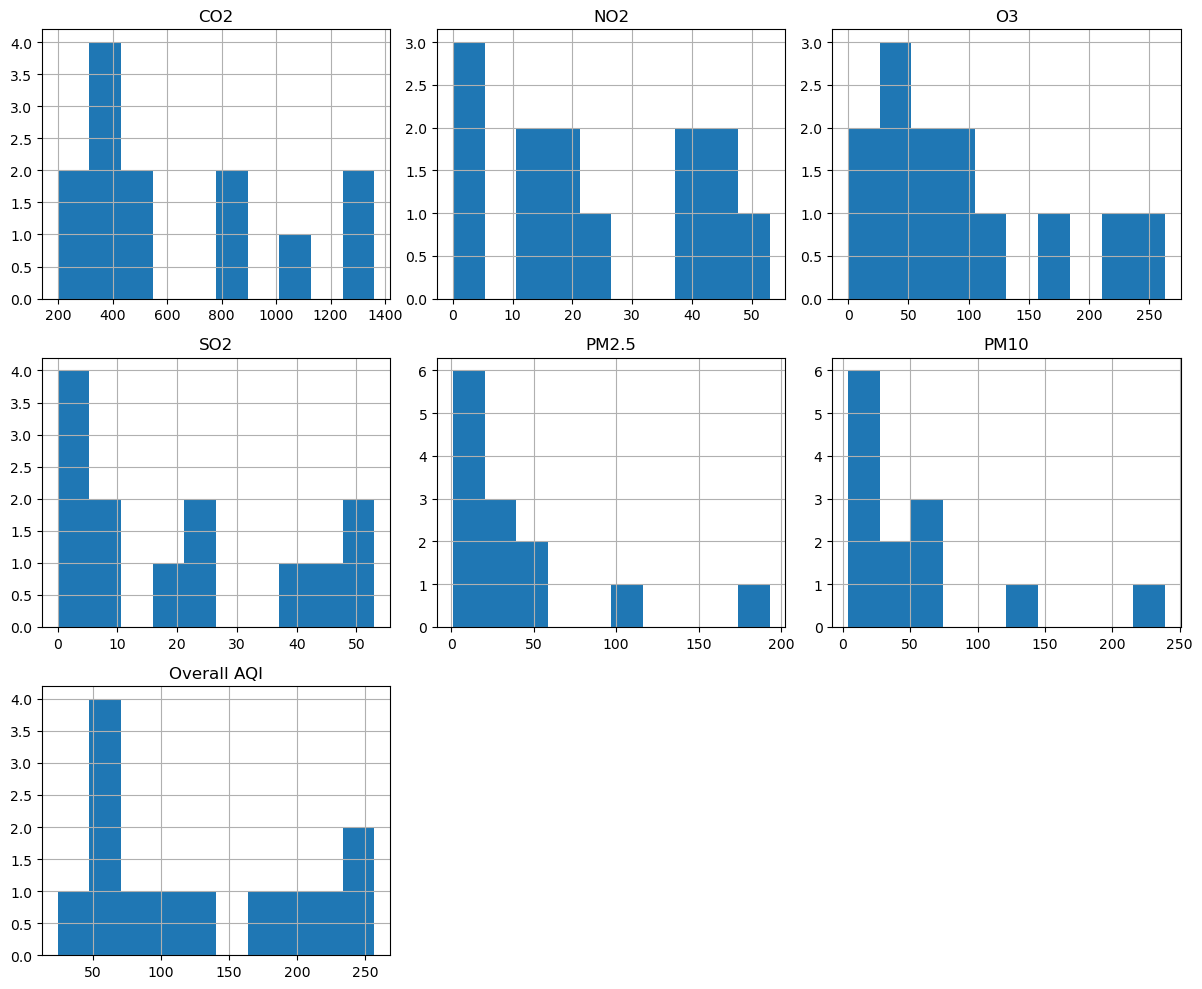

In [326]:
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

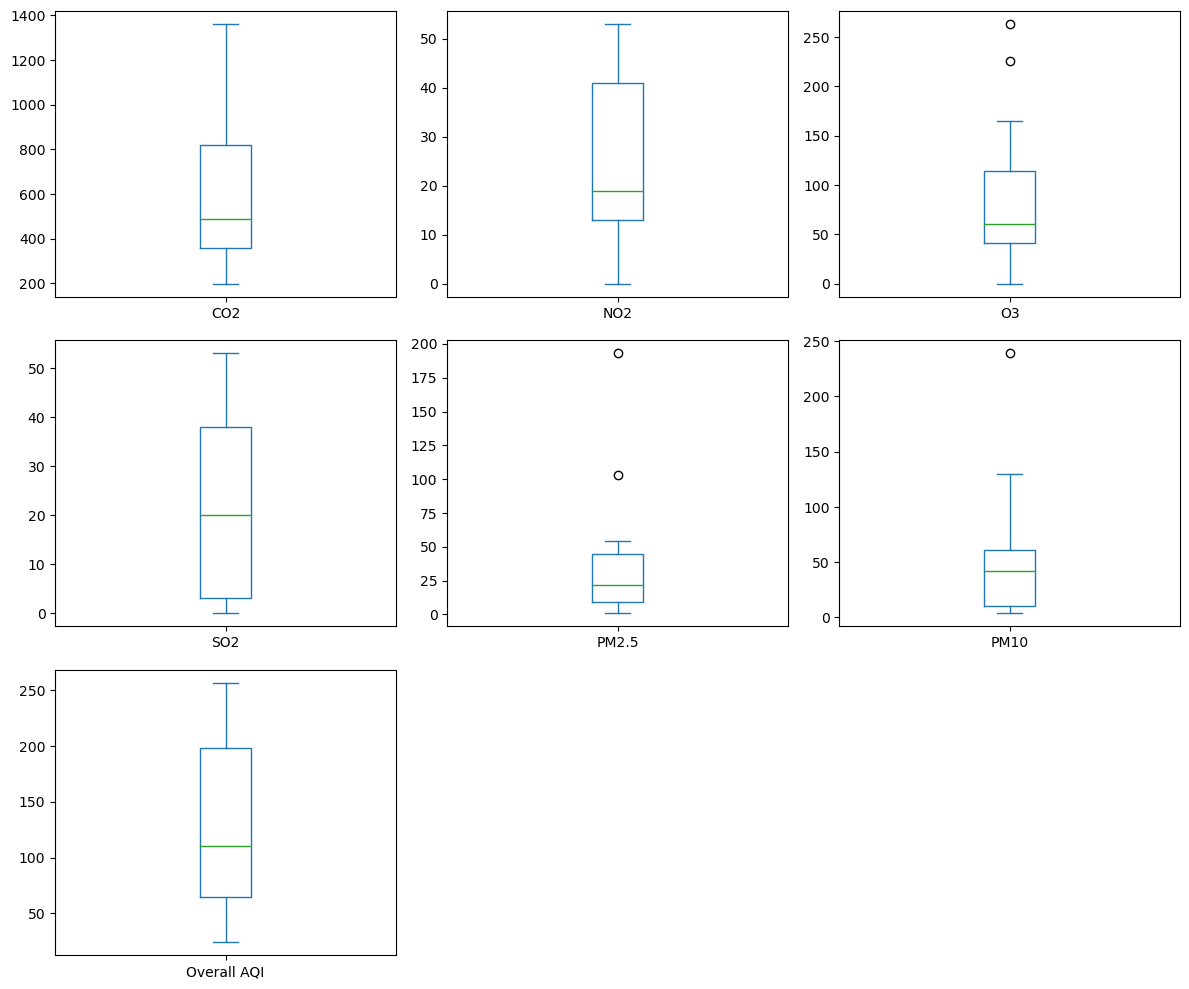

In [327]:
df.plot(kind='box', subplots=True, layout=(3, 3), figsize=(12, 10), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

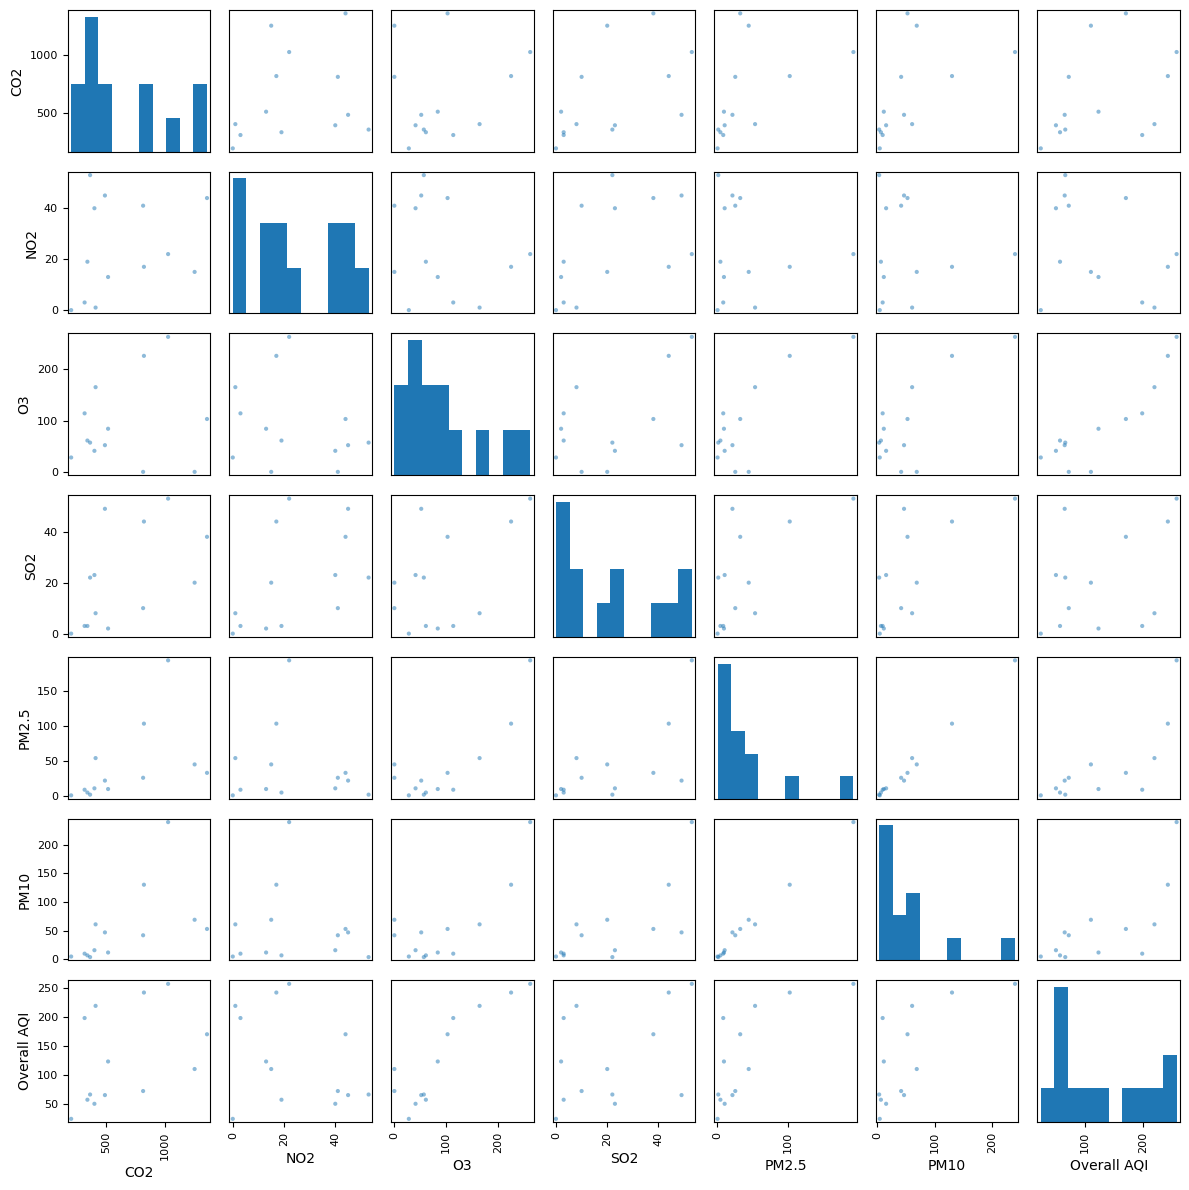

In [328]:
pd.plotting.scatter_matrix(df, figsize=(12, 12))
plt.tight_layout()
plt.show()

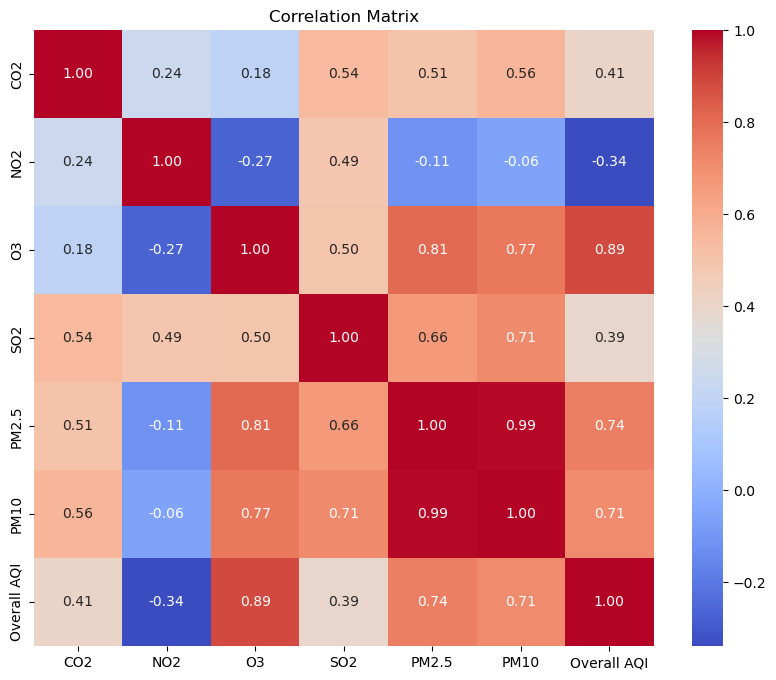

In [329]:
int_df = df.drop('City', axis=1) 
int_df = int_df.drop('Country', axis=1)

correlation_matrix = int_df.corr()
plt.figure(figsize=(10, 8))
plt.title('Correlation Matrix')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

### Data Visualizations

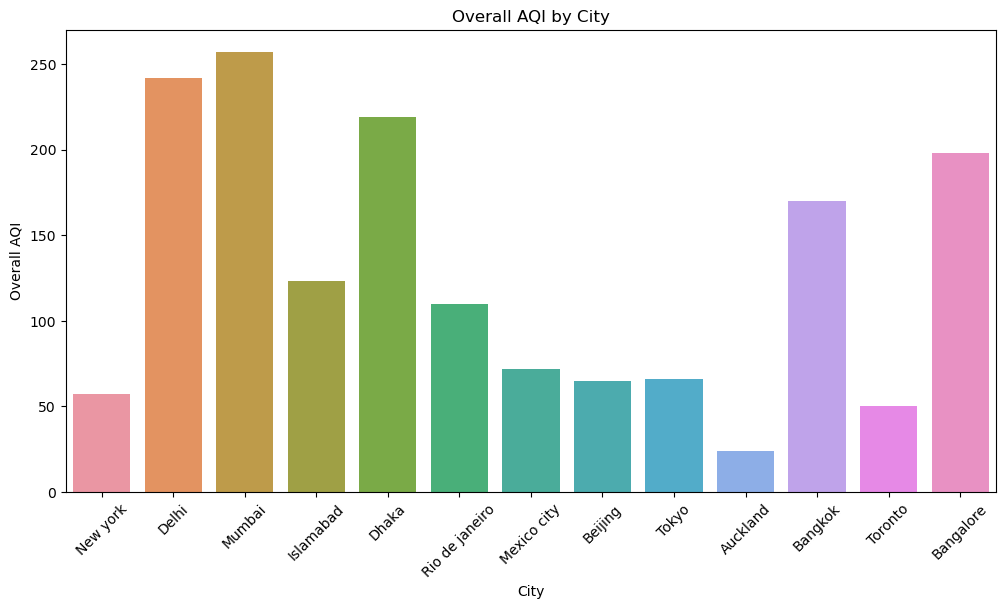

In [330]:
plt.figure(figsize=(12, 6))
sns.barplot(x='City', y='Overall AQI', data=df)
plt.xticks(rotation=45)
plt.title('Overall AQI by City')
plt.xlabel('City')
plt.ylabel('Overall AQI')
plt.show()

This visualization provides a clear comparison of air quality levels by utilizing a bar plot to show the total Air Quality Index (AQI) across various cities.

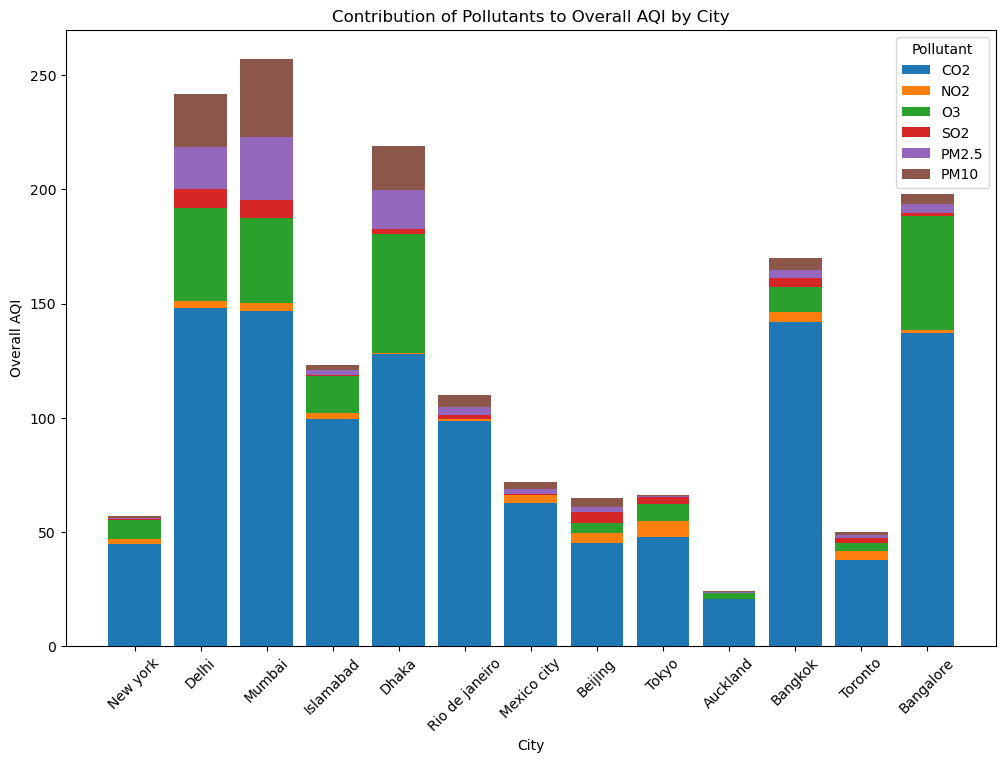

In [331]:
plt.figure(figsize=(12, 8))

df['Total_Pollutants'] = df[['CO2', 'NO2', 'O3', 'SO2', 'PM2.5', 'PM10']].sum(axis=1)
for pollutant in ['CO2', 'NO2', 'O3', 'SO2', 'PM2.5', 'PM10']:
    df[pollutant + '_Contribution'] = df[pollutant] / df['Total_Pollutants']

sns.barplot(x='City', y='Overall AQI', data=df, color='grey')
bottom = 0
for pollutant in ['CO2', 'NO2', 'O3', 'SO2', 'PM2.5', 'PM10']:
    plt.bar(df['City'], df[pollutant + '_Contribution'] * df['Overall AQI'], bottom=bottom, label=pollutant)
    bottom += df[pollutant + '_Contribution'] * df['Overall AQI']
    
plt.title('Contribution of Pollutants to Overall AQI by City')
plt.xlabel('City')
plt.ylabel('Overall AQI')
plt.xticks(rotation=45)
plt.legend(title='Pollutant')
plt.show()


The proportion of each pollutant to the total AQI is displayed using a stacked bar plot, which provides information on the relative effects of the various pollutants on different cities.

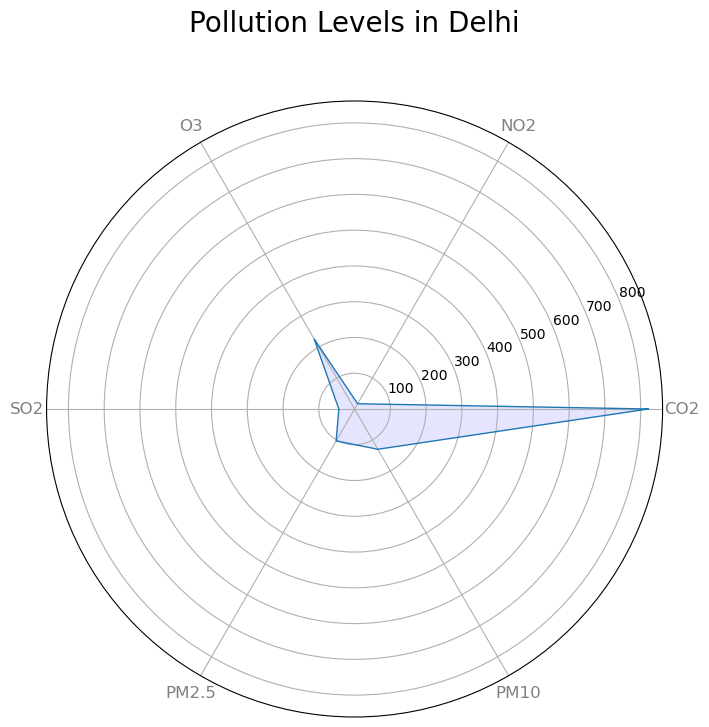

In [332]:
city = 'Delhi'

city_data = df[df['City'] == city][['CO2', 'NO2', 'O3', 'SO2', 'PM2.5', 'PM10']].mean()

categories = list(city_data.index)
N = len(categories)

values = city_data.values.tolist()
values += values[:1]
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

plt.xticks(angles[:-1], categories, color='grey', size=12)

ax.plot(angles, values, linewidth=1, linestyle='solid')

ax.fill(angles, values, 'b', alpha=0.1)

plt.title(f'Pollution Levels in {city}', size=20, color='black', y=1.1)

plt.show()



This visualization employed a radar graphic to display the pollution levels in Delhi, a particular city, providing a thorough overview of different pollutant concentrations.

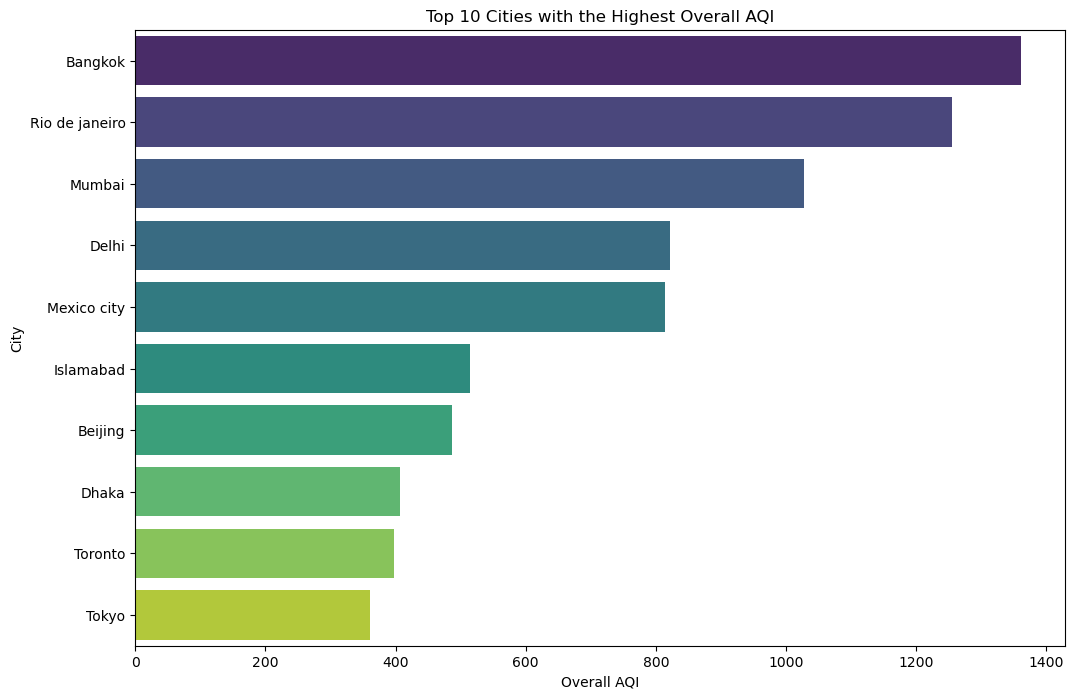

In [333]:
plt.figure(figsize=(12, 8))

top_cities = df.sort_values(by='CO2', ascending=False).head(10)

sns.barplot(x='CO2', y='City', data=top_cities, palette='viridis')
plt.title('Top 10 Cities with the Highest Overall AQI')
plt.xlabel('Overall AQI')
plt.ylabel('City')
plt.show()

In order to shine emphasis on major contributors to air pollution, a bar plot is also used to highlight the top 10 cities with the largest CO2 emissions.

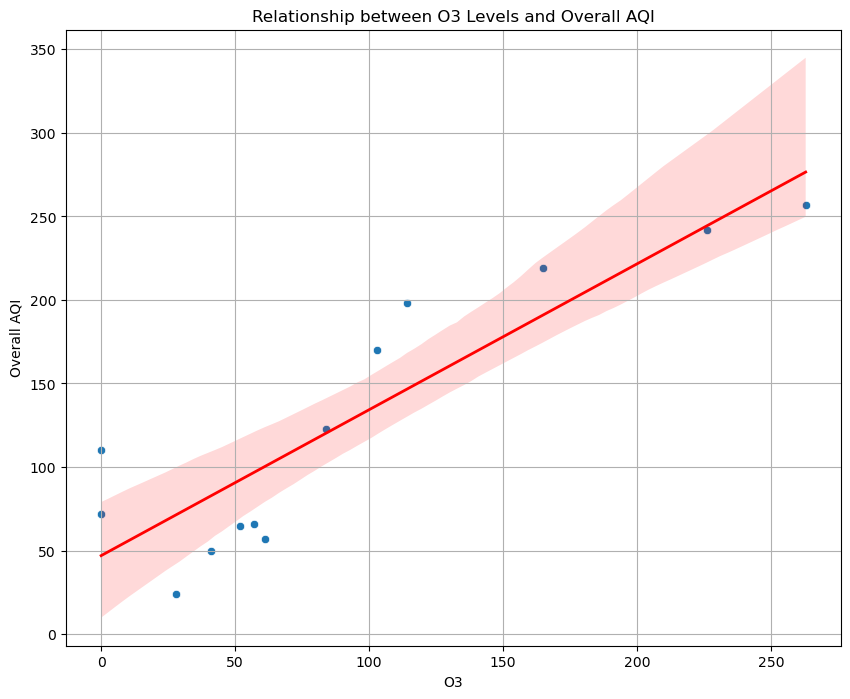

In [334]:
 plt.figure(figsize=(10, 8))

sns.scatterplot(x='O3', y='Overall AQI', data=df)
plt.title('Relationship between O3 Levels and Overall AQI')
plt.xlabel('O3 Levels')
plt.ylabel('Overall AQI')

sns.regplot(x='O3', y='Overall AQI', data=df, scatter=False, color='r', line_kws={'linewidth':2})

plt.grid(True)
plt.show()

In order to gain important insights into pollutant correlations and their effects on air quality, scatter plot is used to investigate associations between O3 levels and overall AQI.

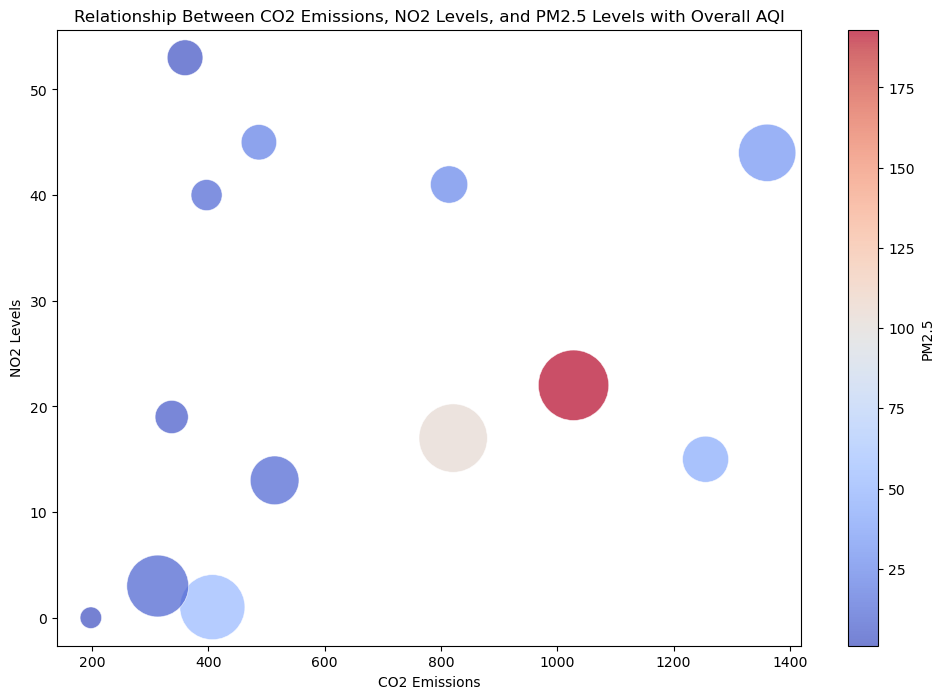

In [335]:
plt.figure(figsize=(12, 8))

x = 'CO2'
y = 'NO2'
size = 'Overall AQI'
color = 'PM2.5'

scatter = plt.scatter(df[x], df[y], s=df[size]*10, c=df[color], cmap='coolwarm', alpha=0.7, edgecolors='w', linewidth=0.5)

plt.colorbar(scatter, label='PM2.5')

plt.title('Relationship Between CO2 Emissions, NO2 Levels, and PM2.5 Levels with Overall AQI')
plt.xlabel('CO2 Emissions')
plt.ylabel('NO2 Levels')

plt.show()


The correlations between CO2 emissions, NO2 levels, PM2.5 concentrations, and Overall AQI were efficiently represented by this bubble graphic, which offered a comprehensive view of the dynamics of pollution across various metropolitan settings.

## K-Means Clustering

In [336]:
features = df[['CO2', 'NO2', 'O3', 
                 'SO2', 'PM2.5', 'PM10', 'Overall AQI']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [337]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=27)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

C:\Users\Tanay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Tanay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tanay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Tanay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are

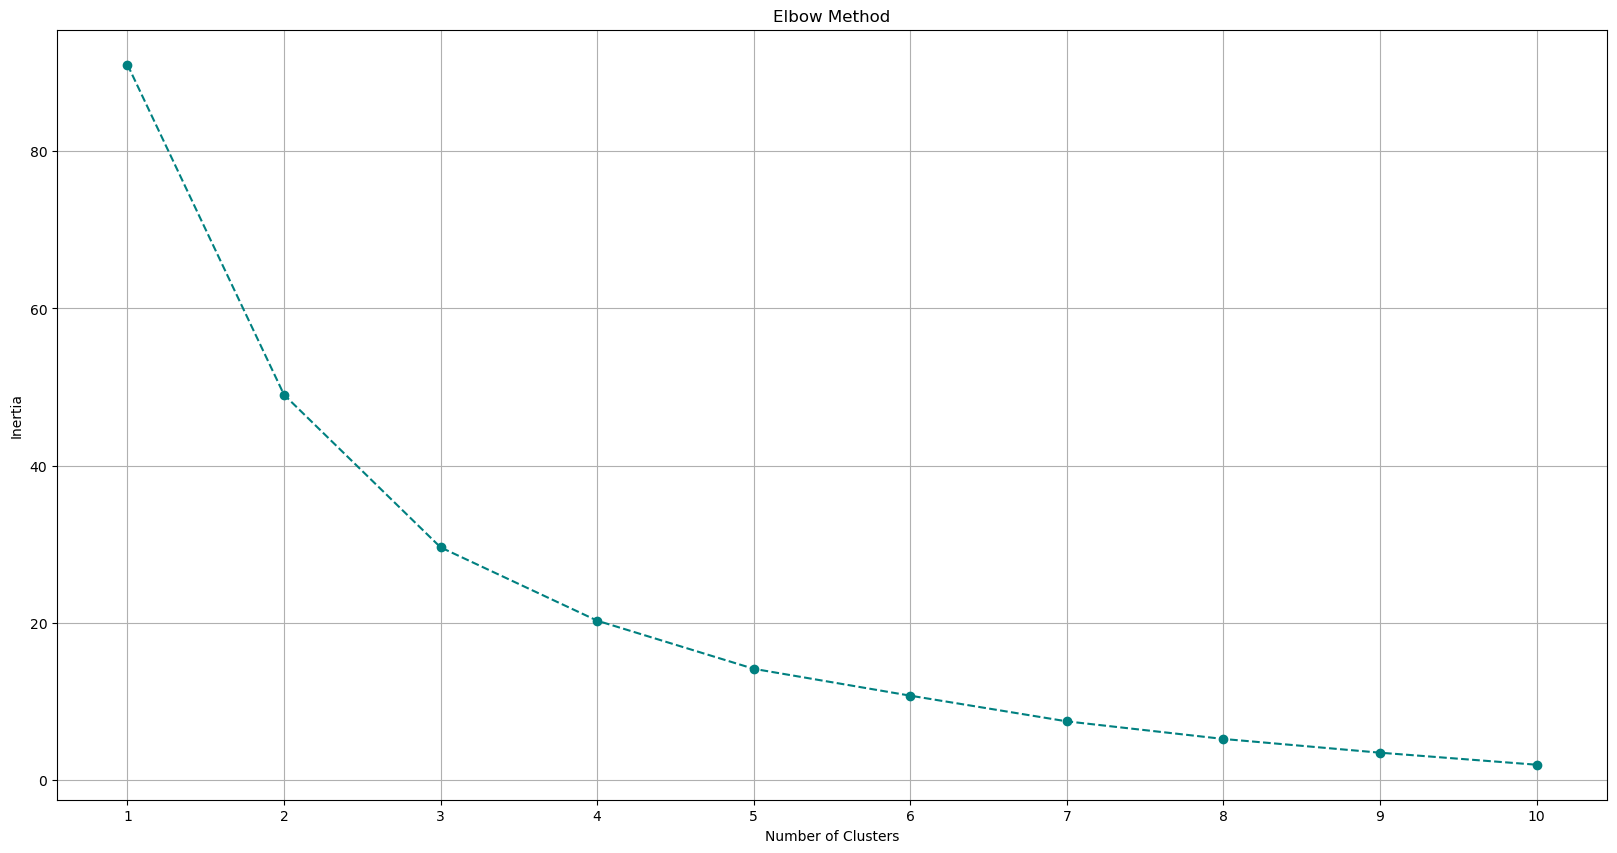

In [338]:
plt.figure(figsize=(20, 10))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--', color = 'teal')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [339]:
optimal_clusters = 2

kmeans = KMeans(n_clusters=optimal_clusters, init='k-means++', random_state=27)
data['Cluster'] = kmeans.fit_predict(scaled_features)

print(data)

C:\Users\Tanay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Tanay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


{'CO': {'concentration': 313.76, 'aqi': 3}, 'NO2': {'concentration': 3.81, 'aqi': 4}, 'O3': {'concentration': 114.44, 'aqi': 198}, 'SO2': {'concentration': 3.99, 'aqi': 5}, 'PM2.5': {'concentration': 9.65, 'aqi': 31}, 'PM10': {'concentration': 10.77, 'aqi': 9}, 'overall_aqi': 198, 'Cluster': array([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])}


In [340]:
optimal_clusters = 3

kmeans = KMeans(n_clusters=optimal_clusters, init='k-means++', random_state=27)
data['Cluster'] = kmeans.fit_predict(scaled_features)

print(data)

C:\Users\Tanay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Tanay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


{'CO': {'concentration': 313.76, 'aqi': 3}, 'NO2': {'concentration': 3.81, 'aqi': 4}, 'O3': {'concentration': 114.44, 'aqi': 198}, 'SO2': {'concentration': 3.99, 'aqi': 5}, 'PM2.5': {'concentration': 9.65, 'aqi': 31}, 'PM10': {'concentration': 10.77, 'aqi': 9}, 'overall_aqi': 198, 'Cluster': array([2, 0, 0, 2, 2, 1, 1, 1, 1, 2, 1, 1, 2])}


In [341]:
optimal_clusters = 4

kmeans = KMeans(n_clusters=optimal_clusters, init='k-means++', random_state=27)
data['Cluster'] = kmeans.fit_predict(scaled_features)

print(data)

C:\Users\Tanay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Tanay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


{'CO': {'concentration': 313.76, 'aqi': 3}, 'NO2': {'concentration': 3.81, 'aqi': 4}, 'O3': {'concentration': 114.44, 'aqi': 198}, 'SO2': {'concentration': 3.99, 'aqi': 5}, 'PM2.5': {'concentration': 9.65, 'aqi': 31}, 'PM10': {'concentration': 10.77, 'aqi': 9}, 'overall_aqi': 198, 'Cluster': array([3, 2, 2, 3, 3, 0, 1, 1, 1, 3, 0, 1, 3])}


In [342]:
optimal_clusters = 5

kmeans = KMeans(n_clusters=optimal_clusters, init='k-means++', random_state=27)
data['Cluster'] = kmeans.fit_predict(scaled_features)

print(data)

C:\Users\Tanay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Tanay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


{'CO': {'concentration': 313.76, 'aqi': 3}, 'NO2': {'concentration': 3.81, 'aqi': 4}, 'O3': {'concentration': 114.44, 'aqi': 198}, 'SO2': {'concentration': 3.99, 'aqi': 5}, 'PM2.5': {'concentration': 9.65, 'aqi': 31}, 'PM10': {'concentration': 10.77, 'aqi': 9}, 'overall_aqi': 198, 'Cluster': array([1, 0, 0, 1, 4, 3, 2, 2, 2, 1, 3, 2, 4])}


#### Silhouette Method

In [343]:
cluster_range = range(2, 10)

silhouette_scores = []

for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=27)
    cluster_labels = kmeans.fit_predict(scaled_features)
    silhouette_avg = silhouette_score(scaled_features, cluster_labels)
    silhouette_scores.append(silhouette_avg)

C:\Users\Tanay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Tanay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tanay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Tanay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are

In [344]:
silhouette_scores

[0.45625255084057154,
 0.3453170690883705,
 0.34711199727846687,
 0.34376842577613687,
 0.2837326881704843,
 0.2561661345823915,
 0.20534377692685712,
 0.21198238824770266]

In [345]:
silhouette_avg

0.21198238824770266

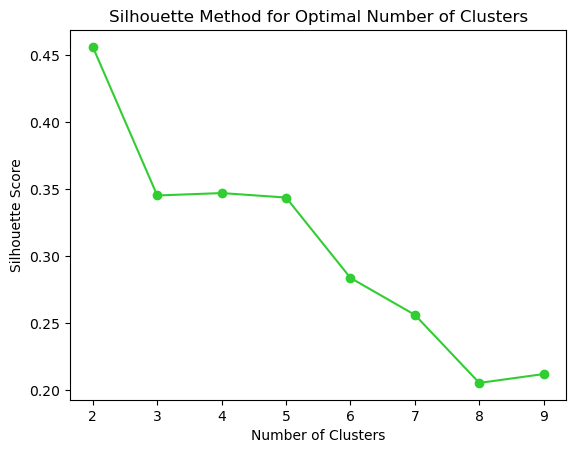

In [346]:
plt.plot(cluster_range, silhouette_scores, marker='o', color = 'limegreen')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal Number of Clusters')
plt.show()

In [347]:
kmeans = KMeans(n_clusters=3).fit(scaled_features)
df['kmeans_cluster'] = kmeans.labels_

C:\Users\Tanay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Tanay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [348]:
kmeans

KMeans(n_clusters=3)

In [349]:
df['kmeans_cluster']

0     1
1     0
2     0
3     1
4     1
5     2
6     2
7     2
8     2
9     1
10    2
11    2
12    1
Name: kmeans_cluster, dtype: int32

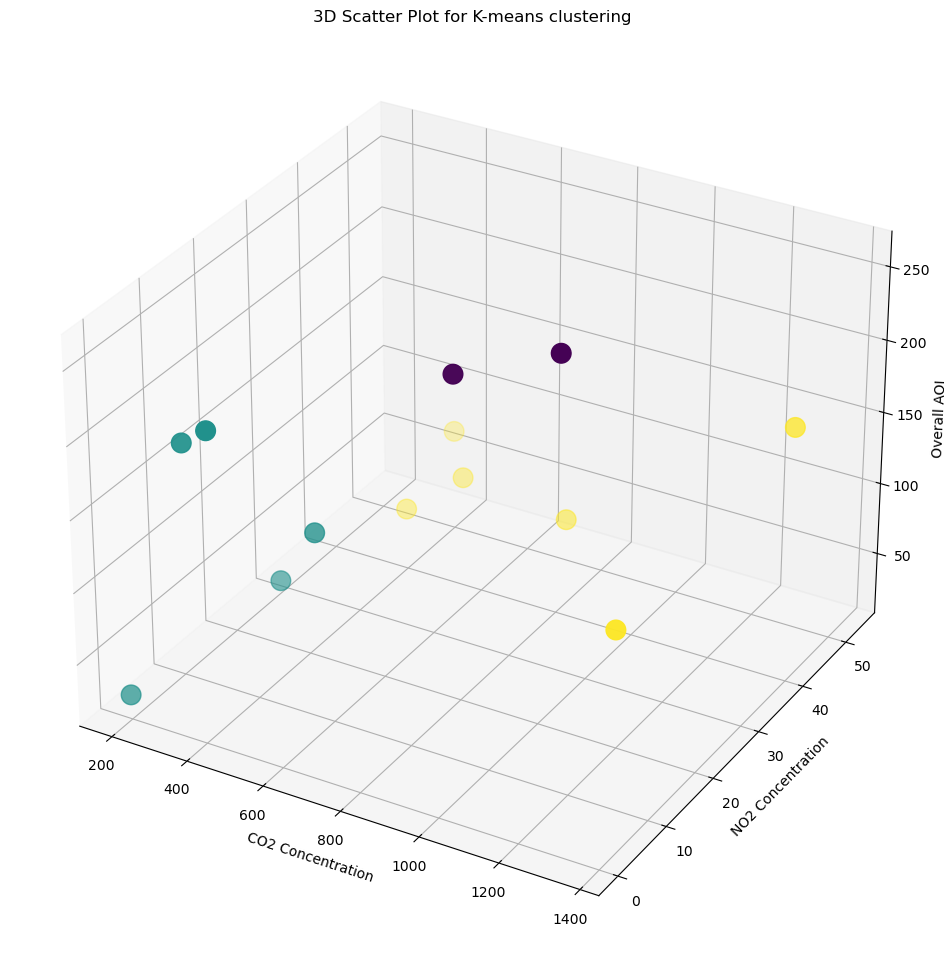

In [350]:
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

x = df['CO2']
y = df['NO2']
z = df['Overall AQI']
c = df['kmeans_cluster']

ax.scatter(x, y, z, c=c, cmap='viridis', s=200)

ax.set_xlabel('CO2 Concentration')
ax.set_ylabel('NO2 Concentration')
ax.set_zlabel('Overall AQI')

plt.title('3D Scatter Plot for K-means clustering')

plt.show()


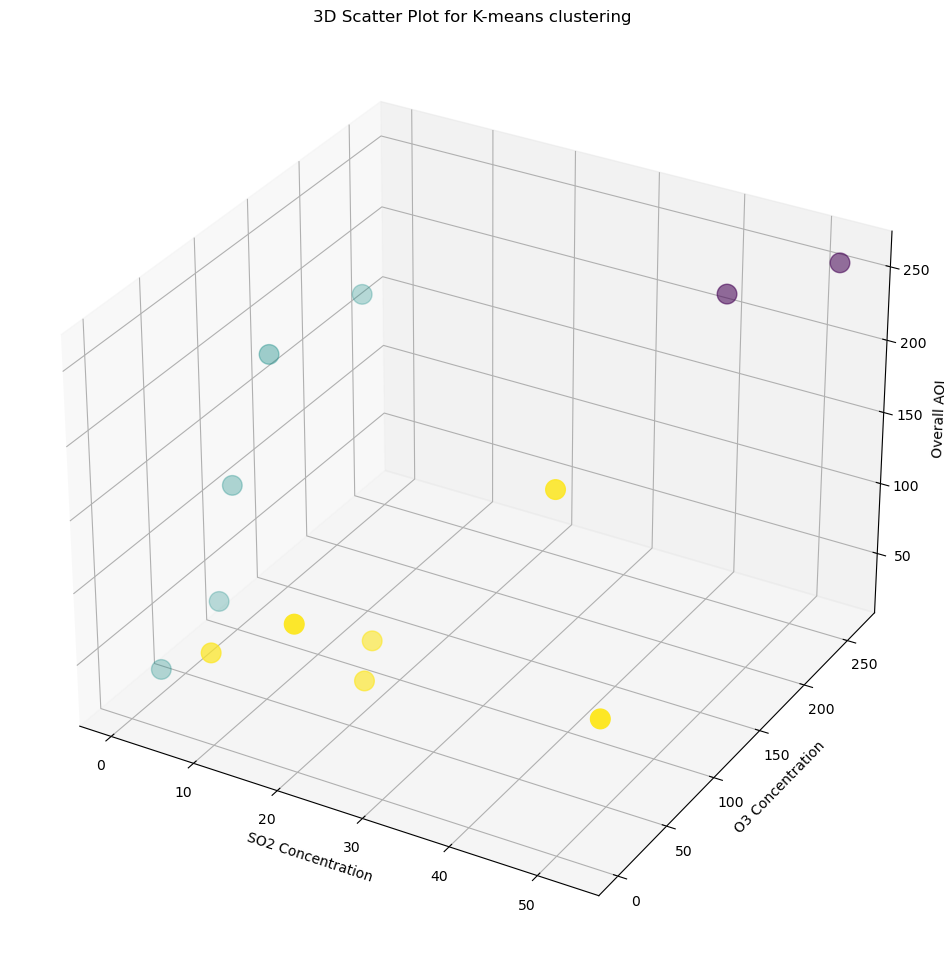

In [351]:
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

x = df['SO2']
y = df['O3']
z = df['Overall AQI']
c = df['kmeans_cluster']

ax.scatter(x, y, z, c=c, cmap='viridis', s=200)

ax.set_xlabel('SO2 Concentration')
ax.set_ylabel('O3 Concentration')
ax.set_zlabel('Overall AQI')

plt.title('3D Scatter Plot for K-means clustering')

plt.show()

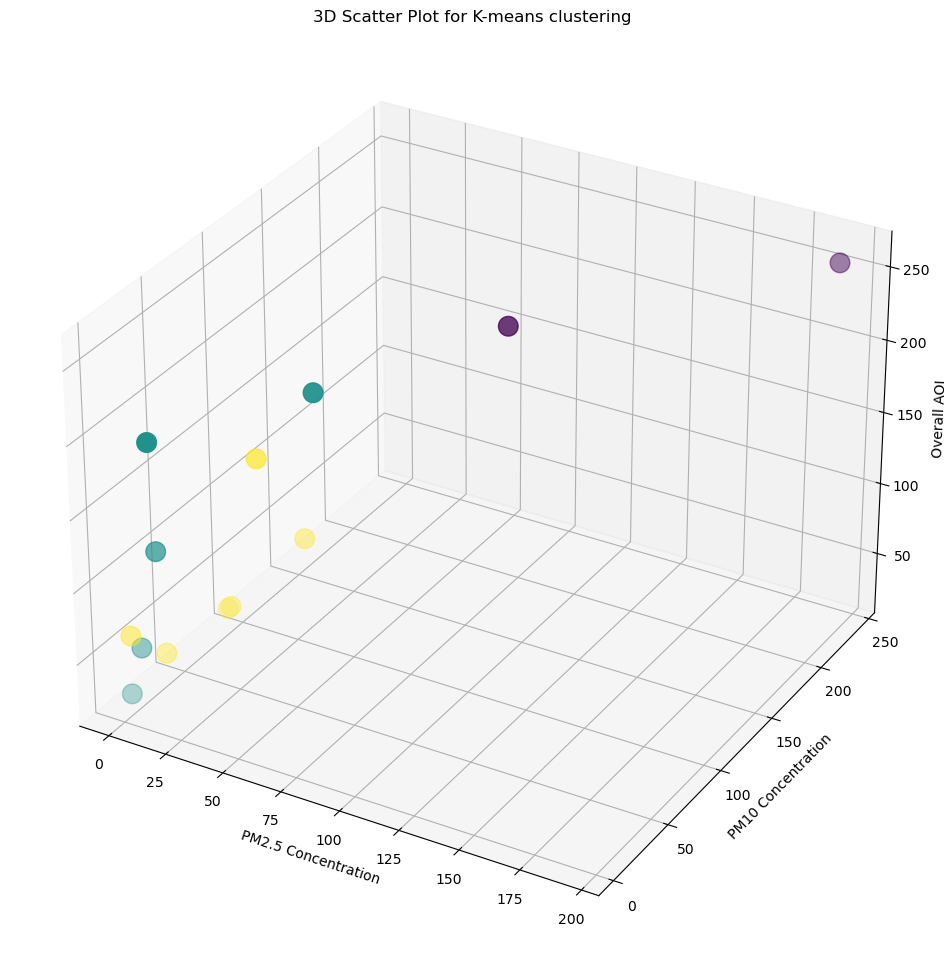

In [352]:
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

x = df['PM2.5']
y = df['PM10']
z = df['Overall AQI']
c = df['kmeans_cluster']

ax.scatter(x, y, z, c=c, cmap='viridis', s=200)

ax.set_xlabel('PM2.5 Concentration')
ax.set_ylabel('PM10 Concentration')
ax.set_zlabel('Overall AQI')

plt.title('3D Scatter Plot for K-means clustering')

plt.show()

C:\Users\Tanay\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


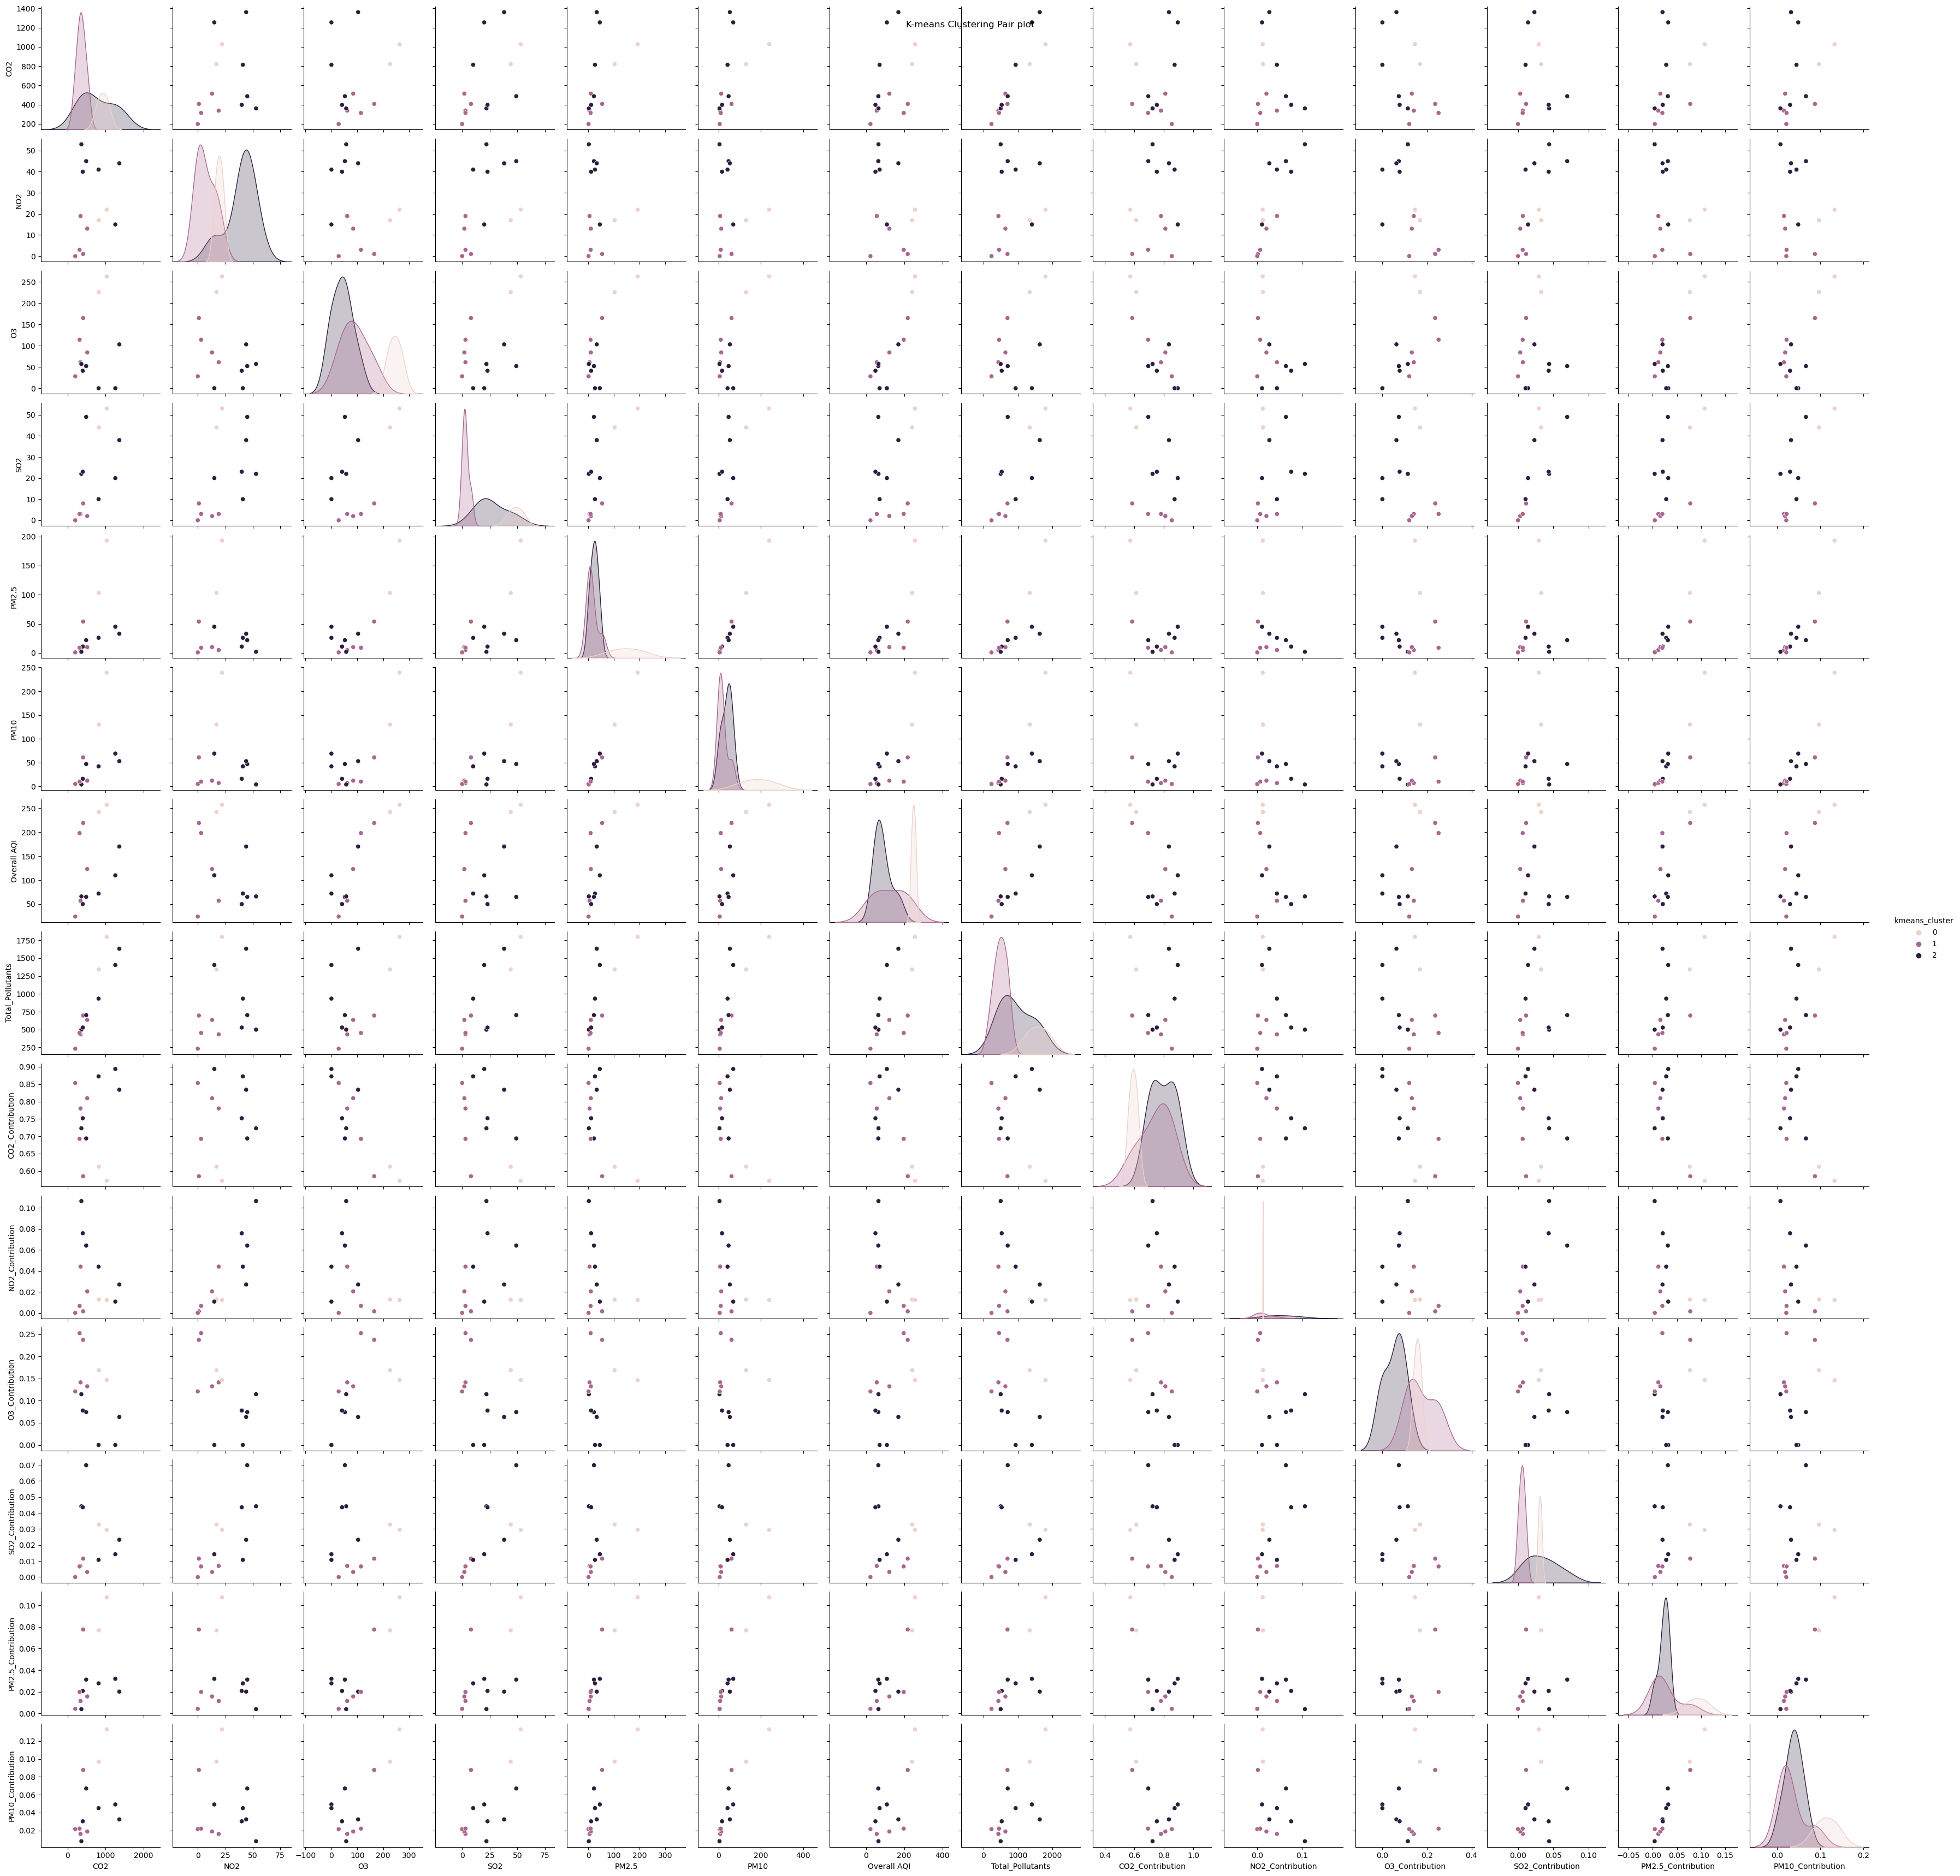

In [353]:
sns.pairplot(df, hue='kmeans_cluster', diag_kind='kde')
plt.suptitle('K-means Clustering Pair plot')
plt.show()

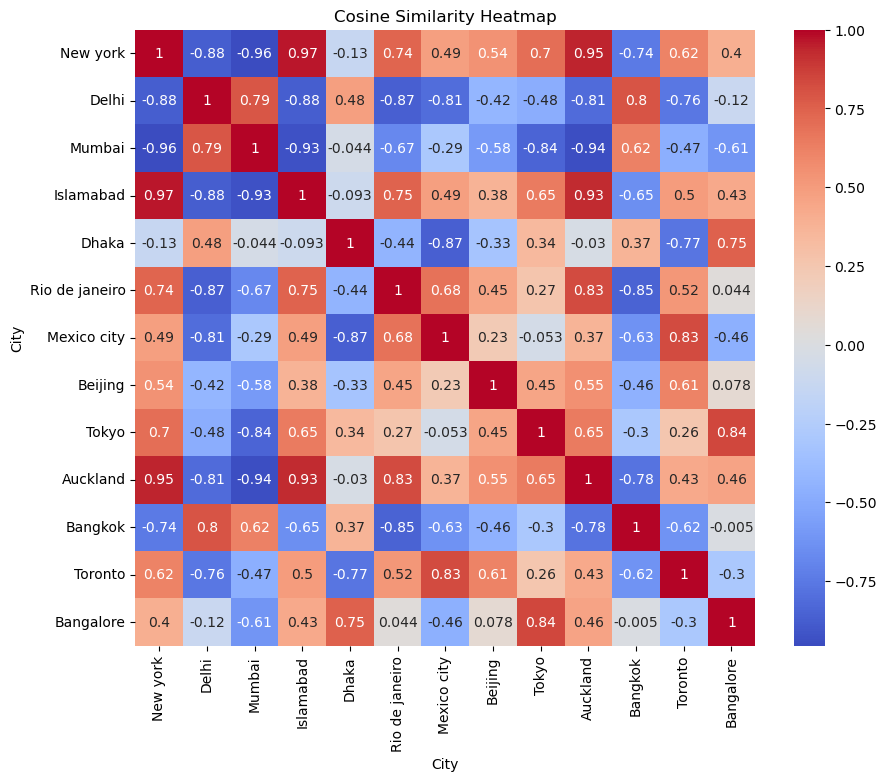

In [354]:
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_sim, annot=True, xticklabels=df['City'], yticklabels=df['City'], cmap='coolwarm')
plt.title('Cosine Similarity Heatmap')
plt.xlabel('City')
plt.ylabel('City')
plt.show()

### Hierarchical Clustering

In [355]:
cosine_sim = cosine_similarity(scaled_features)

In [356]:
linkage_matrix = linkage(cosine_sim, "average")

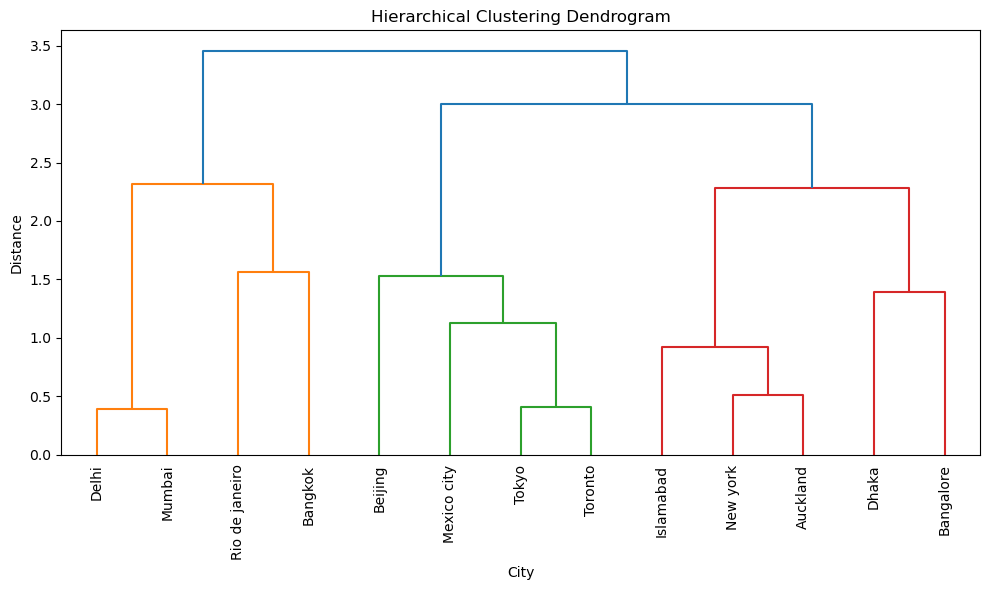

In [357]:
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, labels=df['City'].values, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('City')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [358]:
cluster = AgglomerativeClustering(n_clusters=3, affinity='cosine', linkage='average')
cluster.fit_predict(scaled_features)

df['Cluster'] = cluster.labels_

C:\Users\Tanay\anaconda3\Lib\site-packages\sklearn\cluster\_agglomerative.py:1005: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


In [359]:
df

,City,Country,CO2,NO2,O3,SO2,PM2.5,PM10,Overall AQI,Total_Pollutants,CO2_Contribution,NO2_Contribution,O3_Contribution,SO2_Contribution,PM2.5_Contribution,PM10_Contribution,kmeans_cluster,Cluster
0,New york,United States,337,19,61,3,5,7,57,432,0.780093,0.043981,0.141204,0.006944,0.011574,0.016204,1,0
1,Delhi,India,821,17,226,44,103,130,242,1341,0.612230,0.012677,0.168531,0.032811,0.076808,0.096943,0,1
2,Mumbai,India,1028,22,263,53,193,239,257,1798,0.571746,0.012236,0.146274,0.029477,0.107341,0.132925,0,1
3,Islamabad,Pakistan,514,13,84,2,10,12,123,635,0.809449,0.020472,0.132283,0.003150,0.015748,0.018898,1,0
4,Dhaka,Bangladesh,407,1,165,8,54,61,219,696,0.584770,0.001437,0.237069,0.011494,0.077586,0.087644,1,1
5,Rio de janeiro,Brazil,1255,15,0,20,45,69,110,1404,0.893875,0.010684,0.000000,0.014245,0.032051,0.049145,2,2
6,Mexico city,Mexico,814,41,0,10,26,42,72,933,0.872454,0.043944,0.000000,0.010718,0.027867,0.045016,2,0
7,Beijing,China,487,45,52,49,22,47,65,702,0.693732,0.064103,0.074074,0.069801,0.031339,0.066952,2,0
8,Tokyo,Japan,360,53,57,22,2,4,66,498,0.722892,0.106426,0.114458,0.044177,0.004016,0.008032,2,0
9,Auckland,New Zealand,198,0,28,0,1,5,24,232,0.853448,0.000000,0.120690,0.000000,0.004310,0.021552,1,0


### Principal Component Analysis

In [360]:
pca = PCA()
principal_components = pca.fit_transform(scaled_features)

principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7'])
principal_df[['City', 'Country']] = df[['City', 'Country']]
principal_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,City,Country
0,-1.780989,0.554316,-0.181419,-0.257054,0.187876,-0.277158,-0.015724,New york,United States
1,3.066965,0.486769,-0.387218,0.301406,-0.336098,-0.105071,0.000892,Delhi,India
2,5.291513,0.085066,-0.381705,-0.800402,0.371807,-0.013152,-0.000345,Mumbai,India
3,-1.094467,0.977745,0.300352,0.271847,0.140268,-0.148002,-0.007216,Islamabad,Pakistan
4,0.655479,2.088105,-0.116535,0.392676,0.104715,0.130153,0.008452,Dhaka,Bangladesh
5,0.066869,-0.592011,1.960805,-0.531270,-0.296186,0.170200,0.029707,Rio de janeiro,Brazil
6,-1.092727,-1.132125,0.645209,-0.227938,0.709616,0.202439,-0.037120,Mexico city,Mexico
7,-0.352238,-1.752406,-1.057840,-0.235679,-0.703729,0.200738,-0.032671,Beijing,China
8,-1.461312,-1.292401,-1.042027,0.395054,0.401835,0.007984,0.023439,Tokyo,Japan
9,-2.325188,1.297804,0.029017,-0.982522,-0.329235,-0.194610,-0.006766,Auckland,New Zealand


In [361]:
distances = pairwise_distances(principal_components, metric='cosine')

In [362]:
distance_df = pd.DataFrame(distances, columns=principal_df['City'], index=principal_df['City'])
print("Distance Matrix:")
print(distance_df)

Distance Matrix:
City            New york     Delhi    Mumbai  Islamabad     Dhaka  \
City                                                                
New york        0.000000  1.861168  1.873734   0.175071  1.024772   
Delhi           1.861168  0.000000  0.056592   1.606383  0.555279   
Mumbai          1.873734  0.056592  0.000000   1.724525  0.715781   
Islamabad       0.175071  1.606383  1.724525   0.000000  0.594343   
Dhaka           1.024772  0.555279  0.715781   0.594343  0.000000   
Rio de janeiro  1.186819  1.135715  1.011453   1.083312  1.342074   
Mexico city     0.627200  1.758180  1.565375   0.898700  1.753877   
Beijing         1.065543  1.196846  1.141412   1.540165  1.790018   
Tokyo           0.533256  1.654257  1.619987   0.947192  1.654706   
Auckland        0.073102  1.736777  1.748931   0.195822  0.884791   
Bangkok         1.686777  0.676414  0.674620   1.594416  1.466554   
Toronto         0.389700  1.785408  1.719628   0.869227  1.698640   
Bangalore       0

In [363]:
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance_ratio)

Explained Variance Ratio: [6.01132988e-01 2.36936084e-01 9.10096148e-02 4.72251396e-02
 1.88663559e-02 4.75181356e-03 7.80037095e-05]


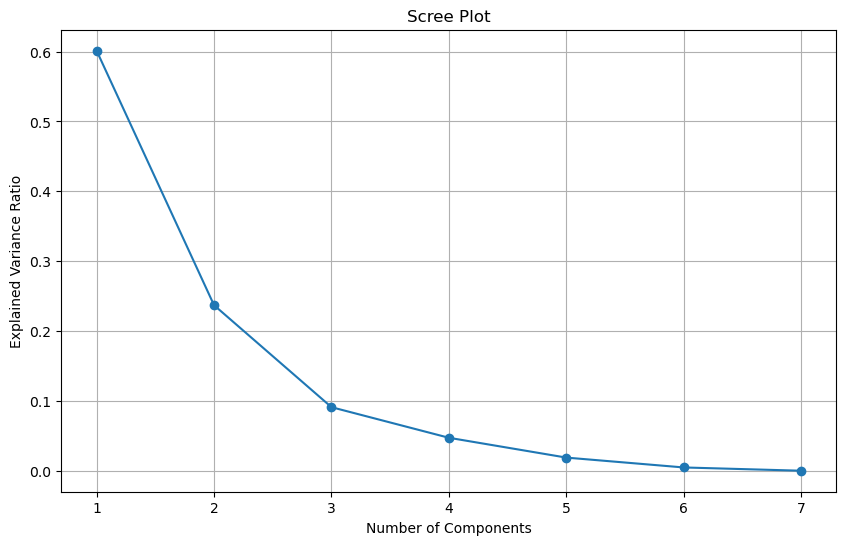

In [364]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, pca.n_components_ + 1), pca.explained_variance_ratio_, marker='o', linestyle='-')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.xticks(np.arange(1, pca.n_components_ + 1))
plt.grid(True)
plt.show()

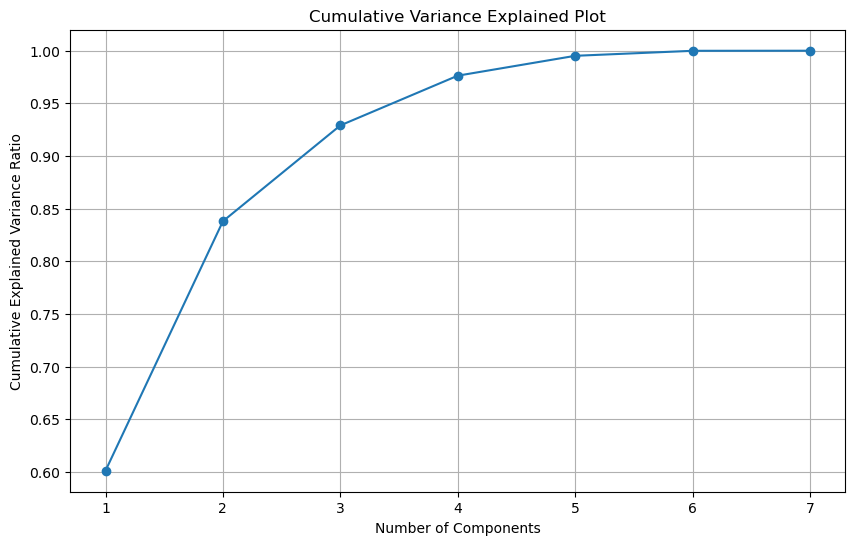

In [365]:
cumulative_variance_ratio = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(10, 6))
plt.plot(range(1, pca.n_components_ + 1), cumulative_variance_ratio, marker='o', linestyle='-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Variance Explained Plot')
plt.xticks(np.arange(1, pca.n_components_ + 1))
plt.grid(True)
plt.show()

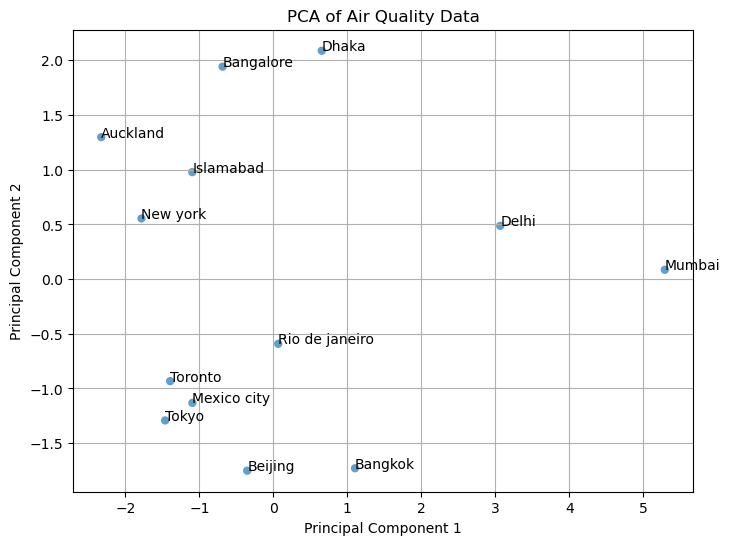

In [366]:
plt.figure(figsize=(8, 6))
plt.scatter(principal_df['PC1'], principal_df['PC2'], edgecolor='none', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Air Quality Data')
for i, city in enumerate(principal_df['City']):
    plt.text(principal_df.loc[i, 'PC1'], principal_df.loc[i, 'PC2'], city)
plt.grid(True)
plt.show()


C:\Users\Tanay\anaconda3\Lib\site-packages\matplotlib\text.py:1279: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if s != self._text:


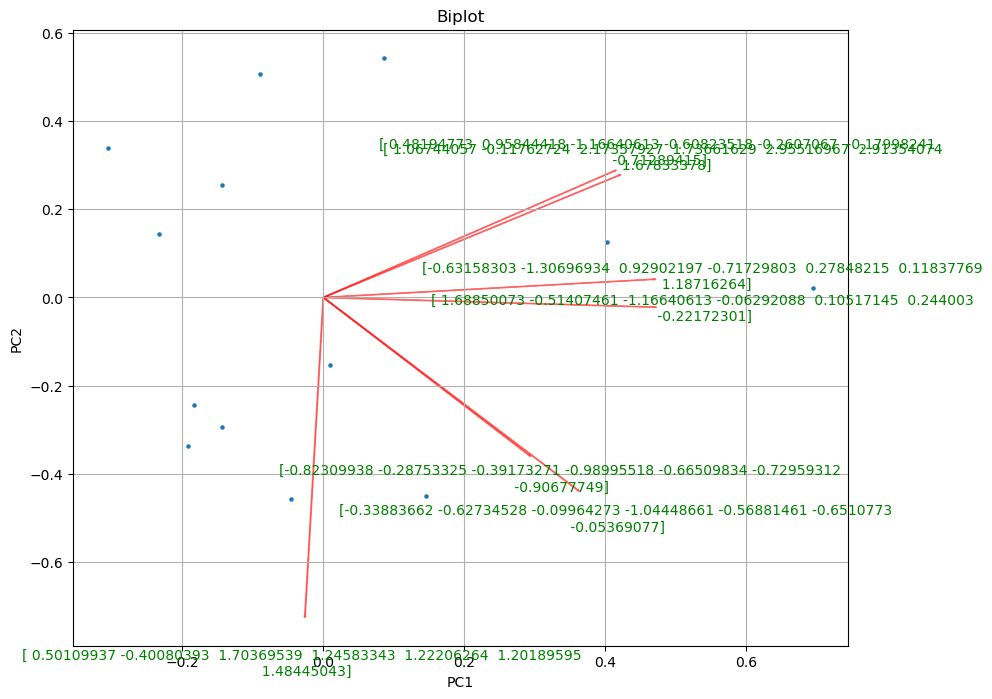

In [367]:
def biplot(score, coeff, labels=None):
    plt.figure(figsize=(10, 8))
    xs = score[:, 0]
    ys = score[:, 1]
    n = coeff.shape[0]
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())
    plt.scatter(xs * scalex, ys * scaley, s=5)
    for i in range(n):
        plt.arrow(0, 0, coeff[i, 0], coeff[i, 1], color='r', alpha=0.5)
        if labels is None:
            plt.text(coeff[i, 0] * 1.15, coeff[i, 1] * 1.15, "Var" + str(i + 1), color='g', ha='center', va='center')
        else:
            plt.text(coeff[i, 0] * 1.15, coeff[i, 1] * 1.15, labels[i], color='g', ha='center', va='center')
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Biplot")
    plt.grid(True)

biplot(principal_components[:, :2], np.transpose(pca.components_[:2, :]), labels=scaled_features)
plt.show()